In [1]:
import pandas as pd

df = pd.read_csv("8486_cleaned_analysis.csv")
print(df.columns.tolist())
print(df['financial_year'].unique())

['Country', 'financial_year', 'calendar_year', 'calendar_month', 'DISCOM', 'State', 'city', 'ev_stations', 'hd_stations', 'ev_kwh', 'hd_kwh', 'total_mu']
<StringArray>
['2023-24', '2022-23']
Length: 2, dtype: str


In [2]:
# Separate the two financial years
fy22 = df[df['financial_year'] == '2022-23']
fy23 = df[df['financial_year'] == '2023-24']

# Sum electricity and stations per state for each year
elec_22 = fy22.groupby('State')['ev_kwh'].sum()
elec_23 = fy23.groupby('State')['ev_kwh'].sum()

stations_22 = fy22.groupby('State')['ev_stations'].sum()
stations_23 = fy23.groupby('State')['ev_stations'].sum()

# Build comparison table
growth = pd.DataFrame({
    'Elec_2022_23': elec_22,
    'Elec_2023_24': elec_23,
    'Stations_2022_23': stations_22,
    'Stations_2023_24': stations_23
}).dropna()

# Calculate growth rates
growth['Elec_Growth_%'] = ((growth['Elec_2023_24'] - growth['Elec_2022_23']) / growth['Elec_2022_23'] * 100).round(1)
growth['Stations_Growth_%'] = ((growth['Stations_2023_24'] - growth['Stations_2022_23']) / growth['Stations_2022_23'] * 100).round(1)

# The key column — demand growing faster than infrastructure?
growth['Demand_vs_Infra'] = (growth['Elec_Growth_%'] - growth['Stations_Growth_%']).round(1)

# Sort by demand vs infra gap
growth = growth.sort_values('Demand_vs_Infra', ascending=False)

print(growth[['Elec_Growth_%', 'Stations_Growth_%', 'Demand_vs_Infra']].to_string())

           Elec_Growth_%  Stations_Growth_%  Demand_vs_Infra
State                                                       
JHARKHAND            inf             -100.0              inf
BIHAR            22740.5             2428.9          20311.6
HARYANA          17552.6              977.4          16575.2
RAJ              10076.9             3870.8           6206.1
KAR               4671.5              518.1           4153.4
ORISSA            4793.2              840.0           3953.2
WB                 961.2              162.2            799.0
MAH                956.4              243.1            713.3
AP                 605.1              215.4            389.7
TN                 339.7               47.6            292.1
ASSAM              750.8              509.3            241.5
TNG                470.2              231.6            238.6
DELHI               79.5               59.6             19.9
KER                417.8              541.3           -123.5
GUJ                237.1

In [5]:
import sys
!{sys.executable} -m pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 1.0 MB/s  0:00:08m0:00:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 1.2 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 1.1 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


Matplotlib is building the font cache; this may take a moment.


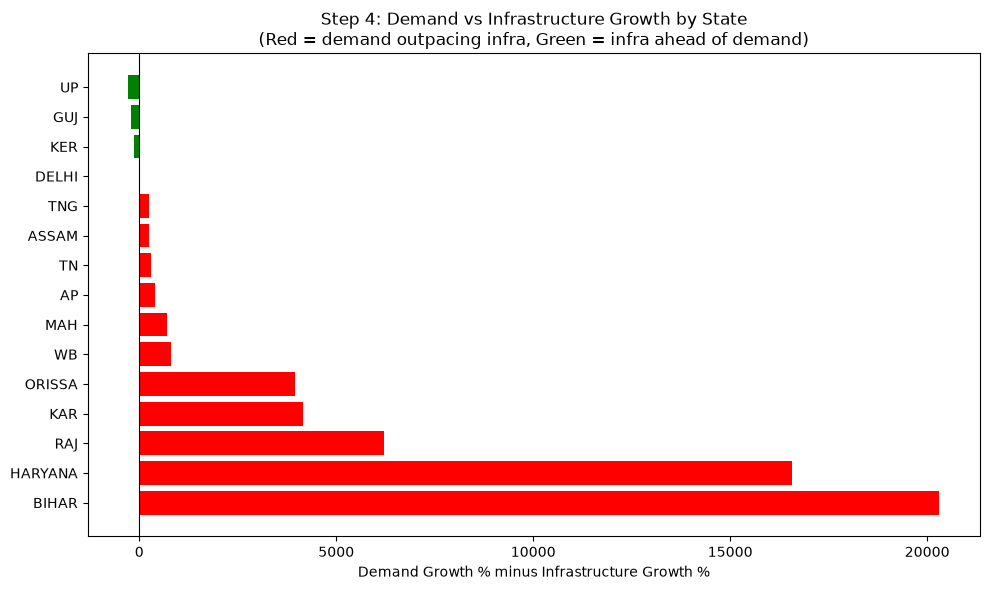

Chart saved!


In [6]:
import matplotlib.pyplot as plt

# Remove JHARKHAND since it has inf values
plot_data = growth[growth['Demand_vs_Infra'] != float('inf')].copy()

plt.figure(figsize=(10, 6))
colors = ['red' if x > 0 else 'green' for x in plot_data['Demand_vs_Infra']]
plt.barh(plot_data.index, plot_data['Demand_vs_Infra'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Demand Growth % minus Infrastructure Growth %')
plt.title('Step 4: Demand vs Infrastructure Growth by State\n(Red = demand outpacing infra, Green = infra ahead of demand)')
plt.tight_layout()
plt.savefig('growth_analysis.png', dpi=150)
plt.show()
print("Chart saved!")

## Step 4: Growth Analysis — Findings

**Method:** Compared electricity consumption growth % vs EV station growth % between 
FY 2022-23 and FY 2023-24 per state. Demand_vs_Infra = Elec_Growth% - Stations_Growth%.
Positive value means demand grew faster than infrastructure.

**Key findings:**
- HARYANA and RAJ show demand growing significantly faster than infrastructure — 
  strongest signal of under-supply after utilisation index
- BIHAR shows extreme values but likely inflated due to near-zero 2022-23 baseline 
  (better reporting in 2023-24 rather than true growth)
- DELHI shows near-zero gap (+19.9) — infrastructure and demand growing proportionately, 
  suggesting healthy balance
- UP, GUJ, KER show negative values — infrastructure growing faster than demand, 
  indicating these states are building ahead of current need

**Limitation:** States with very little 2022-23 data show artificially large growth rates 
due to low baseline. Results for BIHAR, JHARKHAND and ORISSA should be interpreted 
cautiously.

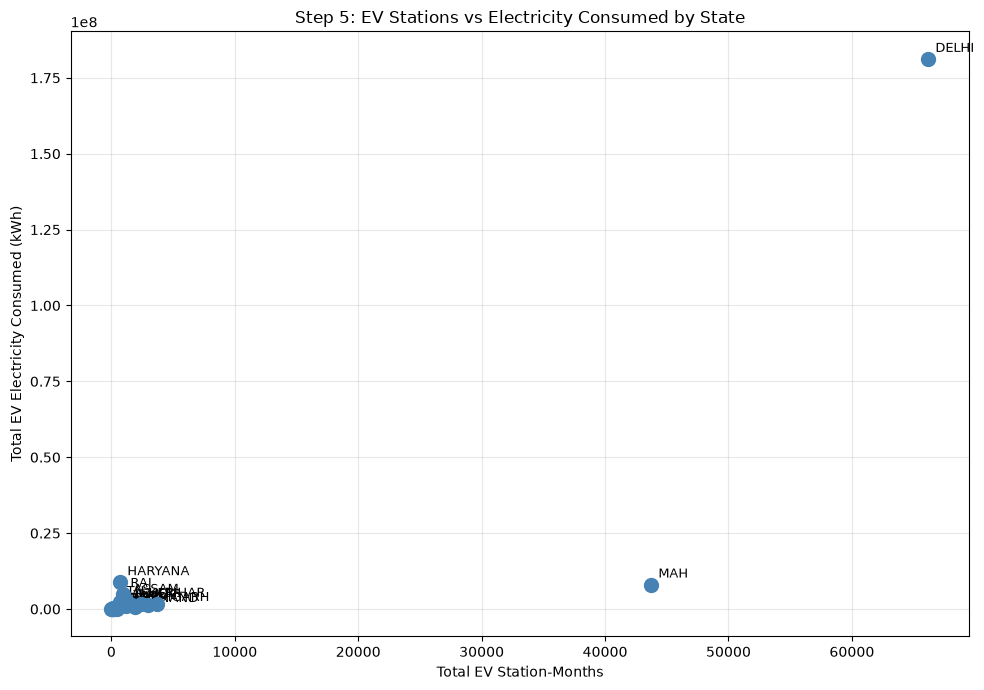

Scatter plot saved!


In [7]:
# Step 5: Scatter plot — Total EV Stations vs Total Electricity consumed per state

# Build state level summary
state_summary = df.groupby('State').agg(
    Total_Stations=('ev_stations', 'sum'),
    Total_Elec_kWh=('ev_kwh', 'sum')
).dropna()

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(state_summary['Total_Stations'], state_summary['Total_Elec_kWh'], 
           color='steelblue', s=100, zorder=5)

# Label each point with state name
for state, row in state_summary.iterrows():
    ax.annotate(state, 
                xy=(row['Total_Stations'], row['Total_Elec_kWh']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9)

ax.set_xlabel('Total EV Station-Months')
ax.set_ylabel('Total EV Electricity Consumed (kWh)')
ax.set_title('Step 5: EV Stations vs Electricity Consumed by State')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scatter_stations_vs_elec.png', dpi=150)
plt.show()
print("Scatter plot saved!")

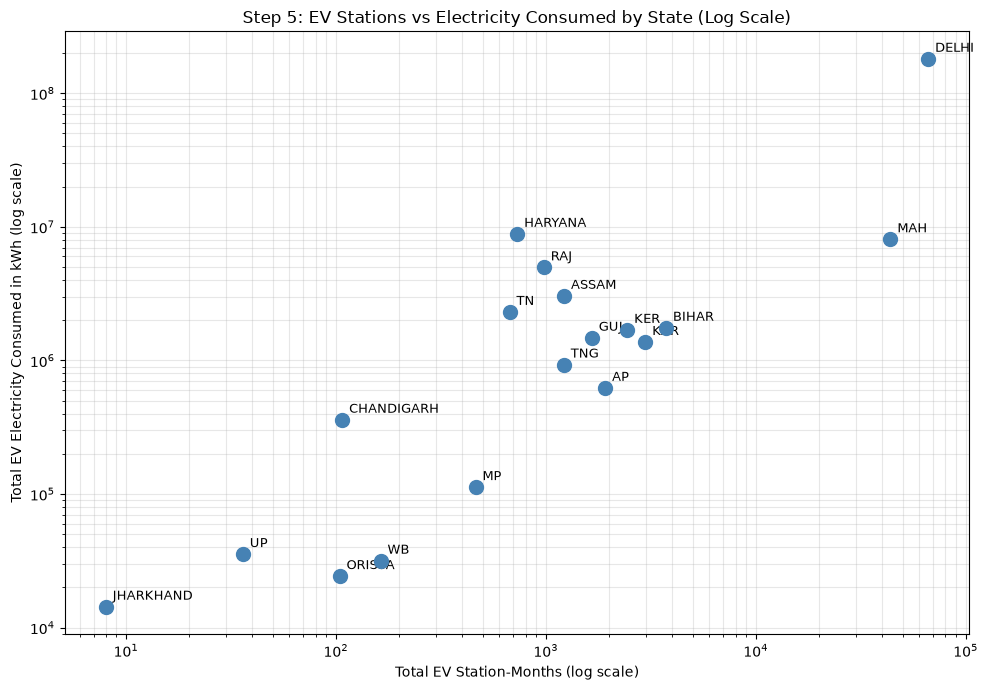

Done!


In [8]:
import numpy as np

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(state_summary['Total_Stations'], state_summary['Total_Elec_kWh'], 
           color='steelblue', s=100, zorder=5)

# Label each point
for state, row in state_summary.iterrows():
    ax.annotate(state, 
                xy=(row['Total_Stations'], row['Total_Elec_kWh']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9)

# Log scale on both axes — this is the fix
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Total EV Station-Months (log scale)')
ax.set_ylabel('Total EV Electricity Consumed in kWh (log scale)')
ax.set_title('Step 5: EV Stations vs Electricity Consumed by State (Log Scale)')
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('scatter_log.png', dpi=150)
plt.show()
print("Done!")